# Superposition with Hadamard, entanglement with CX

Two steps:

1. $H$ puts a qubit into $|+\rangle = (|0\rangle+|1\rangle)/\sqrt{2}$.
2. $CX$ copies that superposition onto a neighbour and produces a **Bell
   pair** $(|00\rangle+|11\rangle)/\sqrt{2}$.

The reduced state of either qubit is maximally mixed — that is the
signature of entanglement. This notebook does not reuse the logic-gates
folder.

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, partial_trace, entropy
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

## One qubit on the Bloch equator

{'1': 2038, '0': 1962}


Matplotlib is building the font cache; this may take a moment.


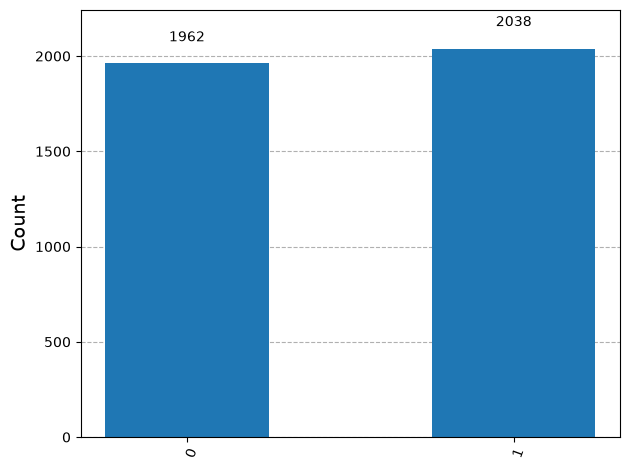

In [2]:
plus = QuantumCircuit(1, 1)
plus.h(0)
plus.measure(0, 0)
sim = AerSimulator()
counts = sim.run(transpile(plus, sim), shots=4000).result().get_counts()
print(counts)
plot_histogram(counts)

## Bell state $|\Phi^+\rangle$

Prepare qubit 0 in $|+\rangle$, then CX onto qubit 1. The only
computational-basis amplitudes that survive are $|00\rangle$ and
$|11\rangle$.

In [3]:
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
print(bell.draw())

sv = Statevector.from_instruction(bell)
print(sv)
print("entropy of qubit 0:", entropy(partial_trace(sv, [1]), base=2))

     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


entropy of qubit 0: 1.0


{'11': 2030, '00': 1970}


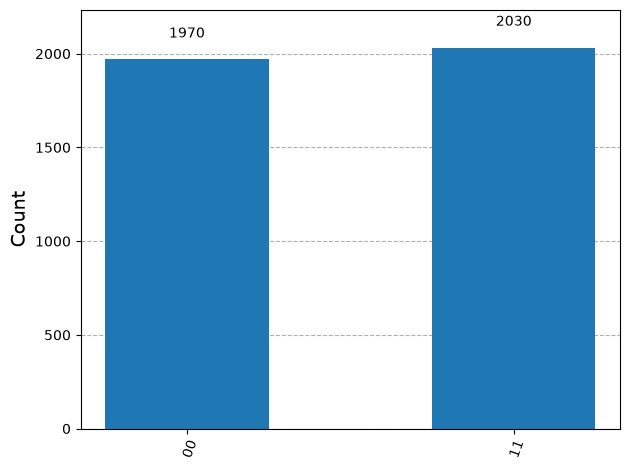

In [4]:
measured = bell.copy()
measured.measure_all()
bell_counts = sim.run(transpile(measured, sim), shots=4000).result().get_counts()
print(bell_counts)
plot_histogram(bell_counts)

## A second Bell state, built differently

$|\Psi^-\rangle = (|01\rangle-|10\rangle)/\sqrt{2}$ uses an $X$ and a
$Z$ before the CX. The two bits now *anti*-correlate.

In [5]:
psi = QuantumCircuit(2)
psi.x(1)
psi.h(0)
psi.z(0)
psi.cx(0, 1)
print(Statevector.from_instruction(psi))
psi.measure_all()
print(sim.run(transpile(psi, sim), shots=4000).result().get_counts())

Statevector([ 0.        +0.j, -0.70710678+0.j,  0.70710678+0.j,
              0.        +0.j],
            dims=(2, 2))


{'01': 1959, '10': 2041}
